# summary.npz 逐 channel 空間快照

conv 層的神經元是攤平的 `(n,)`,`n = oc*h_out*w_out`——直接畫成折線/heatmap 看不出空間結構。
這份 notebook 把它還原成 `(channel, y, x)`,每一格小圖由 `(epoch, quantity, channel)` 三個選項各自獨立決定,
排成一張 `N_ROWS x N_COLS` 的網格,方便同時比較任意組合(不同 epoch、不同量、不同 channel 都可以混著擺)。

還原公式跟排版邏輯在 `viz/channel_grid.py`(通用,不知道 `summary.npz`/`run.yaml` 長怎樣);
怎麼從 `run.yaml` 拿到 conv 層幾何、怎麼從 `summary.npz` 查出某個 `(epoch, quantity, channel)` 對應的圖,是這個專案特有的知識,寫在這份 notebook 裡。

In [6]:
%matplotlib inline
import os

import ipywidgets as widgets
import numpy as np
from IPython.display import display

from example.paths import EXPERIMENTS_DIR
from example.utils import TRACES_DIRNAME, load_run_record, rebuild_layers
from salt_core.layers import ConvLayer
from salt_core.monitor import pack_key
from viz.channel_grid import ImageGridPlot, unflatten_channels

## 參數

改這裡,不改函式庫。`LAYER_NAME` 一次只看一層(要比對不同層,換這個常數重跑);
`N_ROWS`/`N_COLS` 決定網格大小,底下每一格會各自有一組 `epoch`/`quantity`/`channel` 選單。

In [7]:
RUN_NAME = "conv_compressed_compressed_maxsteps_verify_20260912_143647"
LAYER_NAME = "conv1"
N_ROWS = 2
N_COLS = 2

EXP_DIR = EXPERIMENTS_DIR / RUN_NAME
QUANTITIES = ["spike_count", "s_value_sum", "v_final", "idle_frac"]

## 讀 conv 層幾何(來自 run.yaml)+ summary.npz

In [8]:
run_record = load_run_record(str(EXP_DIR))
layers = rebuild_layers(run_record)
layer = next(l for l in layers if l.name == LAYER_NAME)
assert isinstance(layer, ConvLayer), f"{LAYER_NAME} 不是 conv 層,沒有空間結構可以還原"
OC, H, W = layer.oc, layer.h_out, layer.w_out

summary_path = os.path.join(EXP_DIR, TRACES_DIRNAME, "summary.npz")
summary = np.load(summary_path)
EPOCHS = summary["epochs"].tolist()

print(f"{LAYER_NAME}: oc={OC} h_out={H} w_out={W}")
print(f"探測到的 epoch: {EPOCHS}")

conv1: oc=8 h_out=17 w_out=17
探測到的 epoch: [0, 5, 10, 15, 20, 25, 30, 35, 39]


## 解析:一組 (epoch, quantity, channel) → 一張圖

In [9]:
def resolve_frame(epoch: int, quantity: str, channel: int):
    """回傳 (image, title)。`epoch` 要是 EPOCHS 裡實際存在的值——summary.npz
    只在探測到的 epoch 存了一列,不是每個 epoch 都有。"""
    epoch_idx = EPOCHS.index(epoch)
    flat = summary[pack_key(LAYER_NAME, quantity)][epoch_idx]
    img = unflatten_channels(flat, OC, H, W)[channel]
    title = f"{quantity}  ep={epoch}  ch={channel}"
    return img, title

## 互動選擇 + 畫圖

每一格一組 (epoch, quantity, channel) 下拉選單,改完按「畫圖」重畫。

Button(description='畫圖', style=ButtonStyle())

Output()

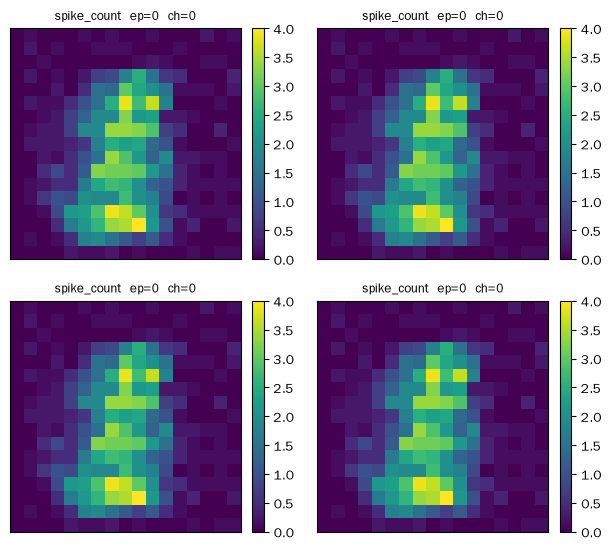

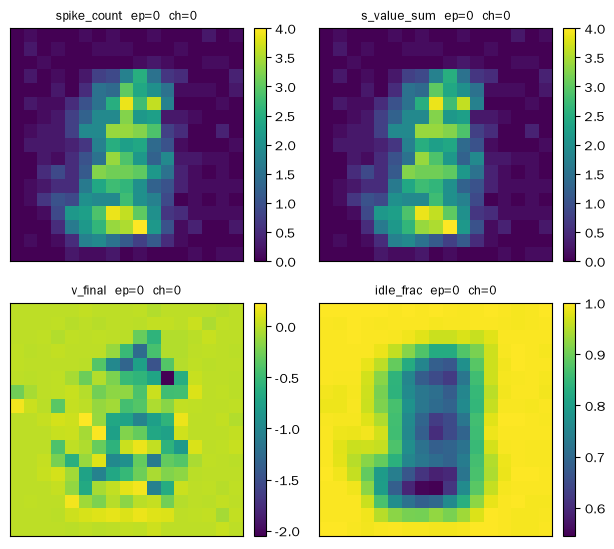

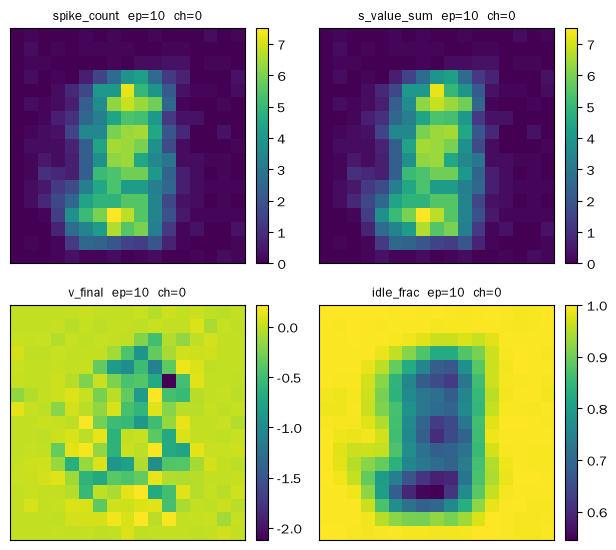

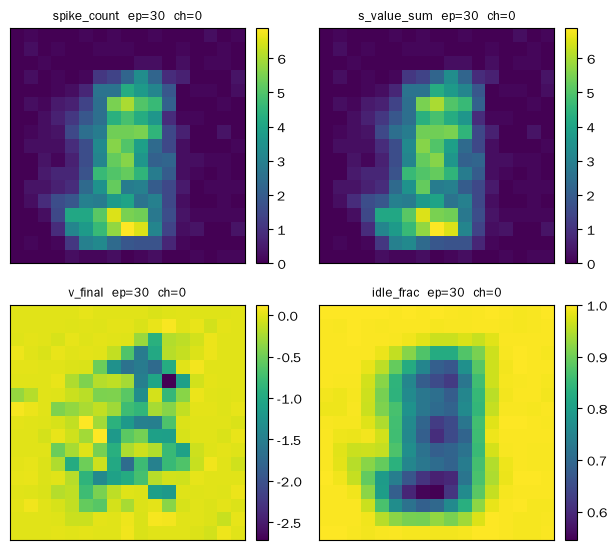

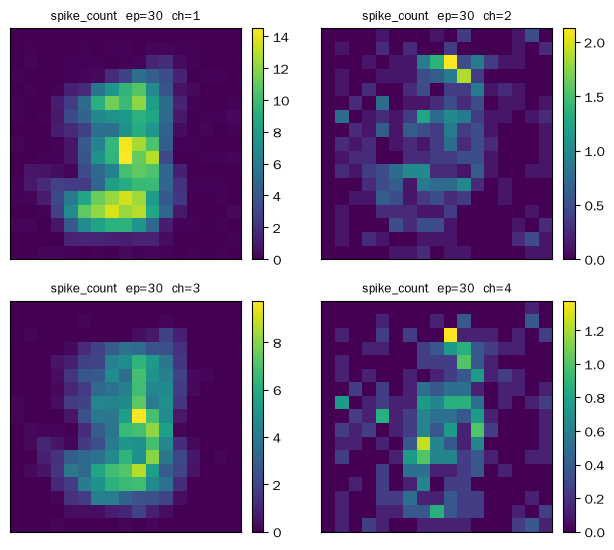

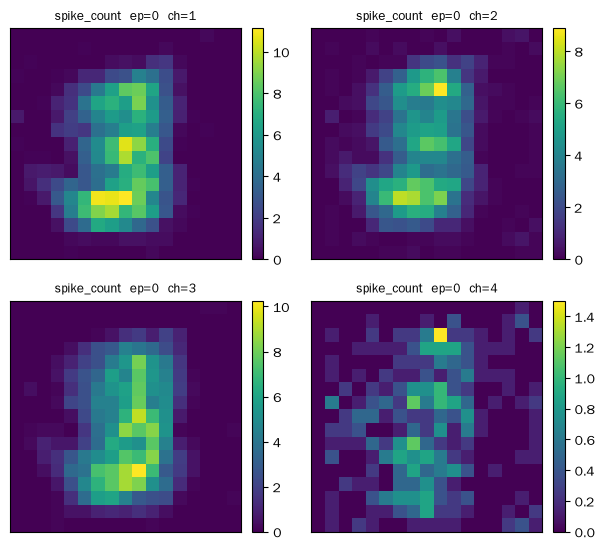

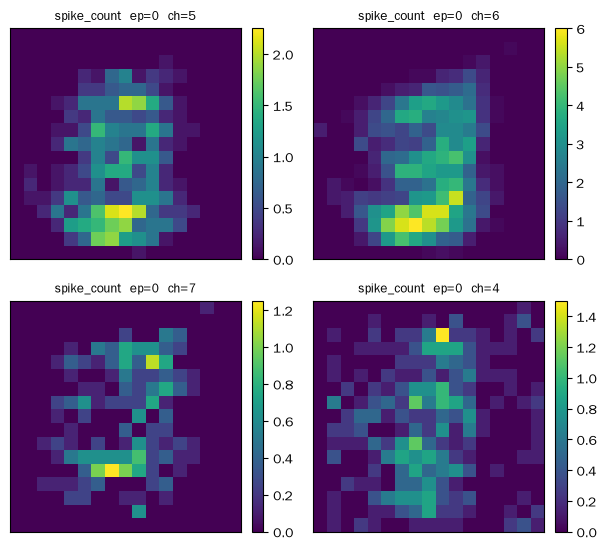

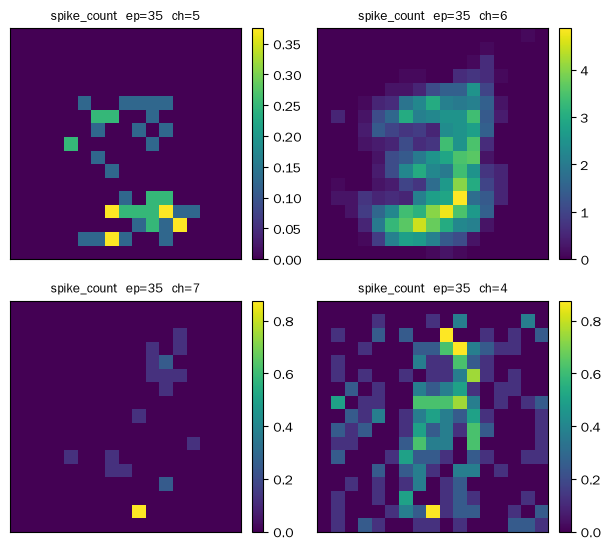

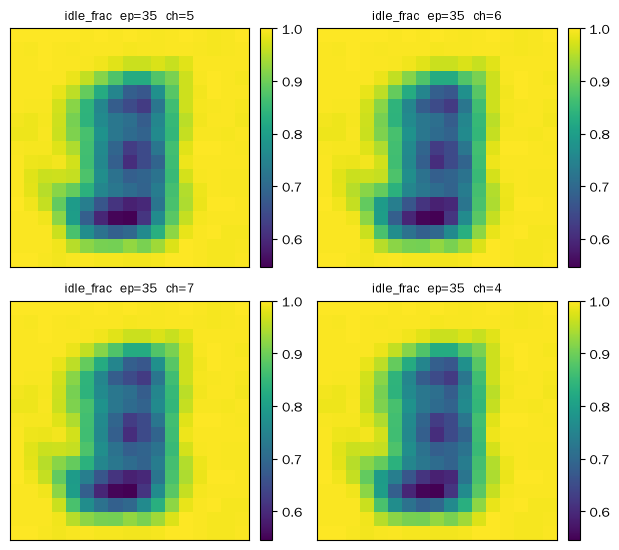

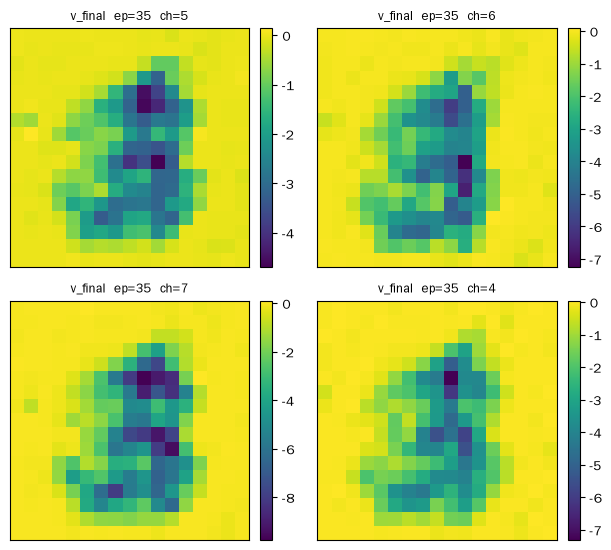

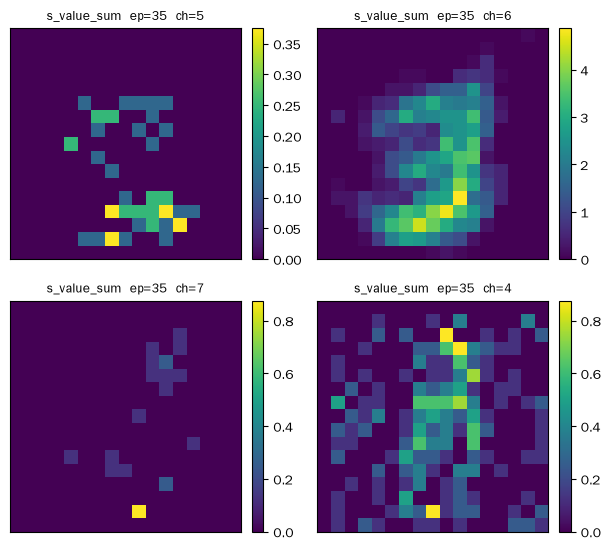

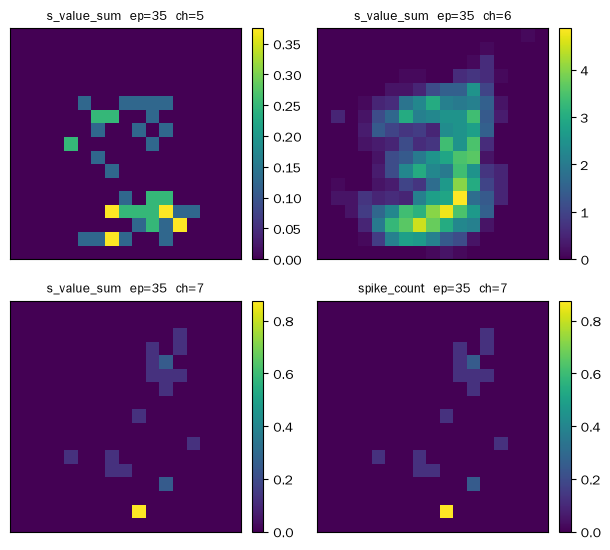

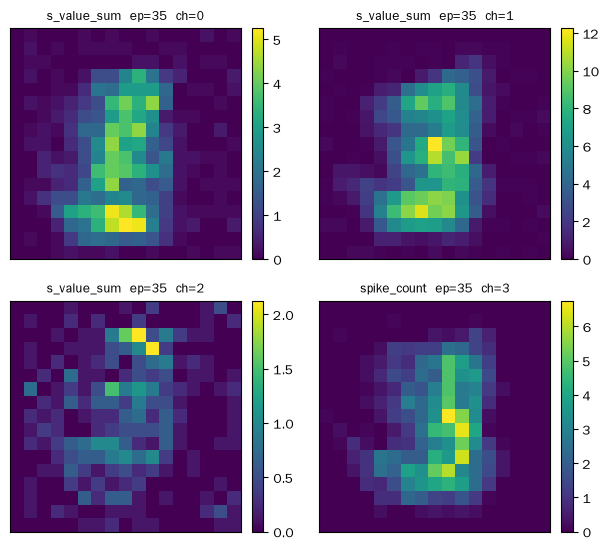

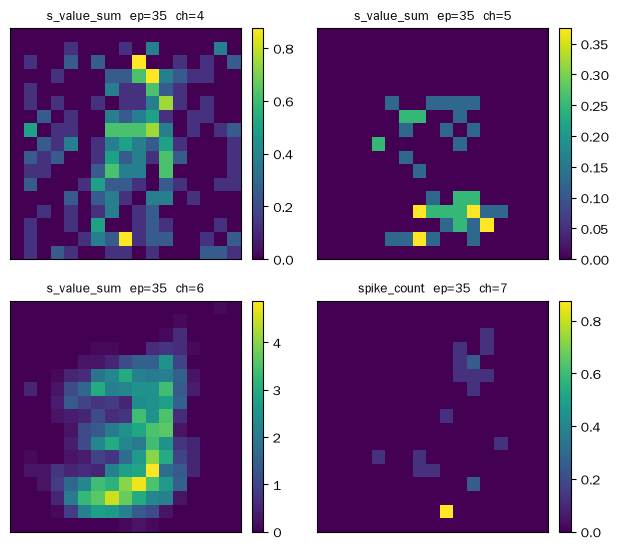

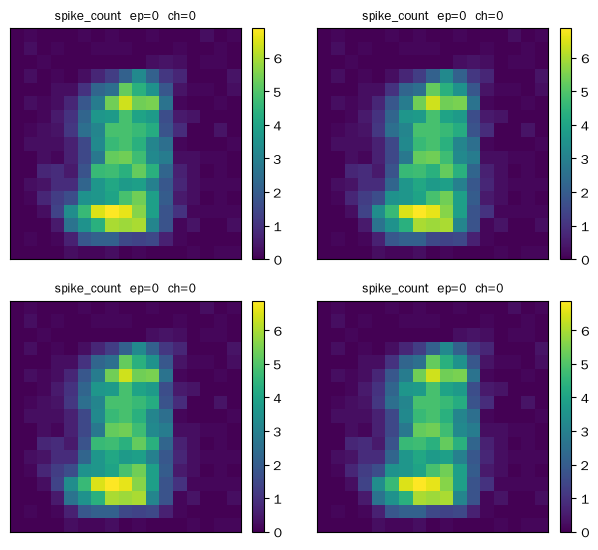

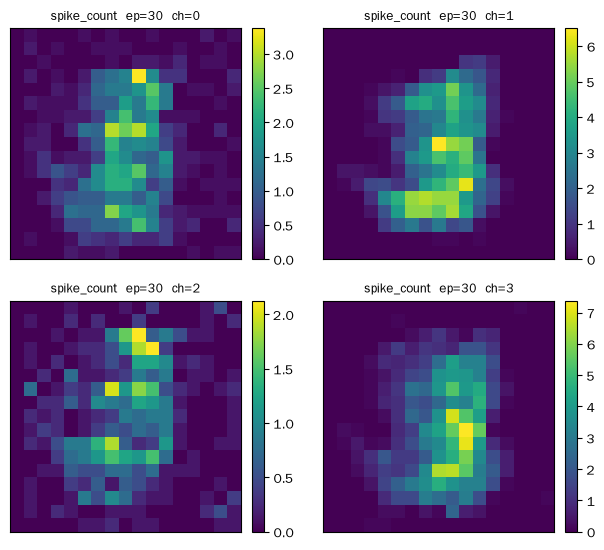

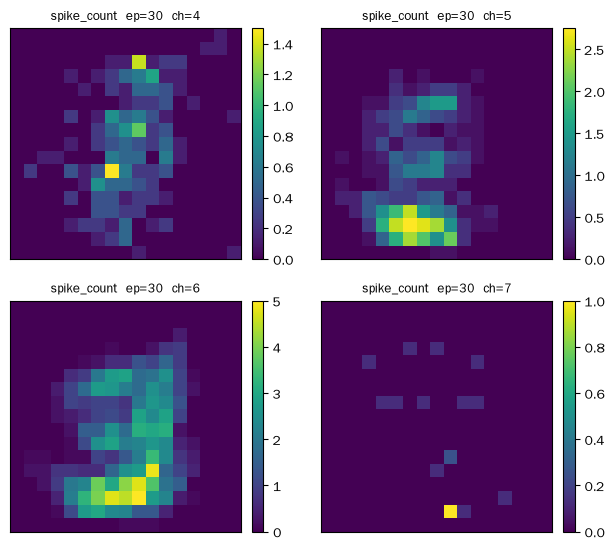

In [10]:
cell_widgets = []
cell_boxes = []
for i in range(N_ROWS * N_COLS):
    epoch_dd = widgets.Dropdown(options=EPOCHS, description="epoch")
    quantity_dd = widgets.Dropdown(options=QUANTITIES, description="quantity")
    channel_dd = widgets.Dropdown(options=list(range(OC)), description="channel")
    cell_widgets.append((epoch_dd, quantity_dd, channel_dd))
    cell_boxes.append(widgets.VBox(
        [widgets.Label(f"格 {i}"), epoch_dd, quantity_dd, channel_dd]))

grid_rows = [widgets.HBox(cell_boxes[r * N_COLS:(r + 1) * N_COLS]) for r in range(N_ROWS)]
controls = widgets.VBox(grid_rows)

redraw_button = widgets.Button(description="畫圖")
output = widgets.Output()


def _redraw(_=None):
    images, titles = [], []
    for epoch_dd, quantity_dd, channel_dd in cell_widgets:
        img, title = resolve_frame(epoch_dd.value, quantity_dd.value, channel_dd.value)
        images.append(img)
        titles.append(title)
    fig = ImageGridPlot(ncols=N_COLS).render(images, titles=titles)
    with output:
        output.clear_output(wait=True)
        display(fig)


redraw_button.on_click(_redraw)
display(controls, redraw_button, output)
_redraw()